In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image

In [4]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.5, 0.5, 0.5],
        std = [0.5, 0.5, 0.5]
    )
])

In [5]:
train_dataset = datasets.ImageFolder(root=r'C:\D_Drive\B.E\Sem-VII\LP-V\DL\PlantVillage', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

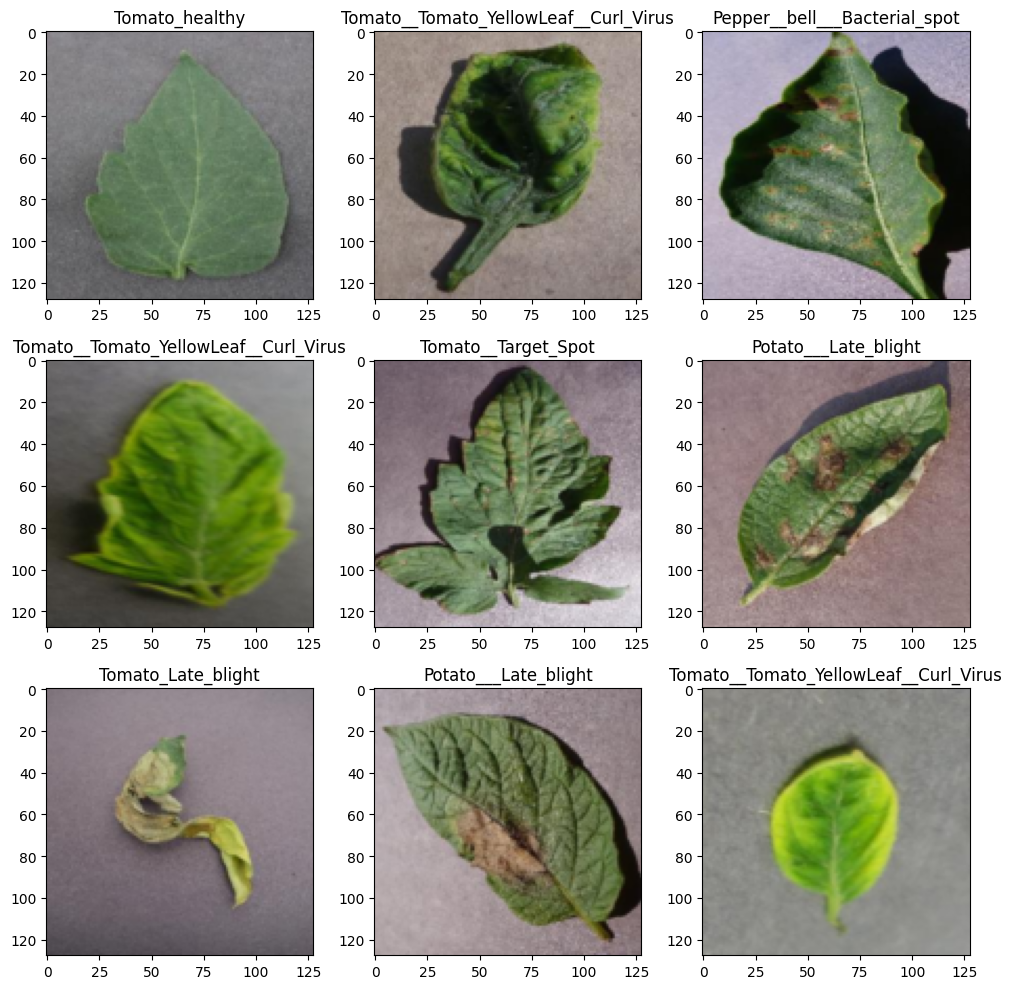

In [25]:
import matplotlib.pyplot as plt
import torchvision

# Get one batch from dataloader
images, labels = next(iter(train_loader))
# Class names
class_names = train_dataset.classes
# Plot images
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    # Convert tensor -> image
    image = images[i].permute(1, 2, 0).numpy()
    # Undo normalization
    image = (image * 0.5) + 0.5
    plt.imshow(image)
    plt.title(class_names[labels[i]])
    # plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
class PlantDiseaseCNN(nn.Module):
    def __init__(self):
        super(PlantDiseaseCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(1),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 128 * 128, 256),
            nn.ReLU(),
            nn.Linear(256, len(train_dataset.classes))
        )
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [8]:
model = PlantDiseaseCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 0

In [9]:
for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')
model.eval()

PlantDiseaseCNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=1048576, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=15, bias=True)
  )
)

In [16]:
img = Image.open(r'C:\D_Drive\B.E\Sem-VII\LP-V\DL\PlantVillage\Tomato_Bacterial_spot\0a6d40e4-75d6-4659-8bc1-22f47cdb2ca8___GCREC_Bact.Sp 6247.JPG')
img.show(title="Input Image")
img = transform(img).unsqueeze(0)
with torch.no_grad():
    output = model(img)
    predicted = torch.argmax(output, dim=1)
    print(f'Predicted class: {train_dataset.classes[predicted.item()]}')


Predicted class: Tomato_Leaf_Mold
